# Time Series Modelling Case Study

### CELL 1: Install Required Libraries

In [1]:
!pip install pmdarima openmeteo-requests requests-cache retry-requests tensorflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.2/777.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.5 MB/s eta 0:00:00


### CELL 2: Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

import itertools

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### CELL 3: Load Dataset

In [3]:
df = pd.read_csv("time_series_60min_singleindex.csv")

df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])
df.set_index('utc_timestamp', inplace=True)

print(df.shape)
df.head()

(46765, 299)


,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 00:00:00+00:00,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00+00:00,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,734.81,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
2015-01-01 02:00:00+00:00,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,766.64,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
2015-01-01 03:00:00+00:00,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,733.13,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


### CELL 4: Select German Load

In [4]:
load = df[['DE_load_actual_entsoe_transparency']]

load.columns = ['load']

load = load.loc['2015-01-01':'2020-10-31']

print(load.shape)
load.head()

(46764, 1)


,load
utc_timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


### CELL 5: Missing Value Handling

In [5]:
print(load.isnull().sum())

load['load'] = load['load'].interpolate(method='time')

load.dropna(inplace=True)

print(load.isnull().sum())

load    0
dtype: int64
load    0
dtype: int64


### CELL 6: Create Daily and Weekly Data

In [6]:
daily = load.resample('D').mean()
weekly = load.resample('W').mean()

print(daily.shape)
print(weekly.shape)

(1949, 1)
(279, 1)


### CELL 7: Hourly Plot

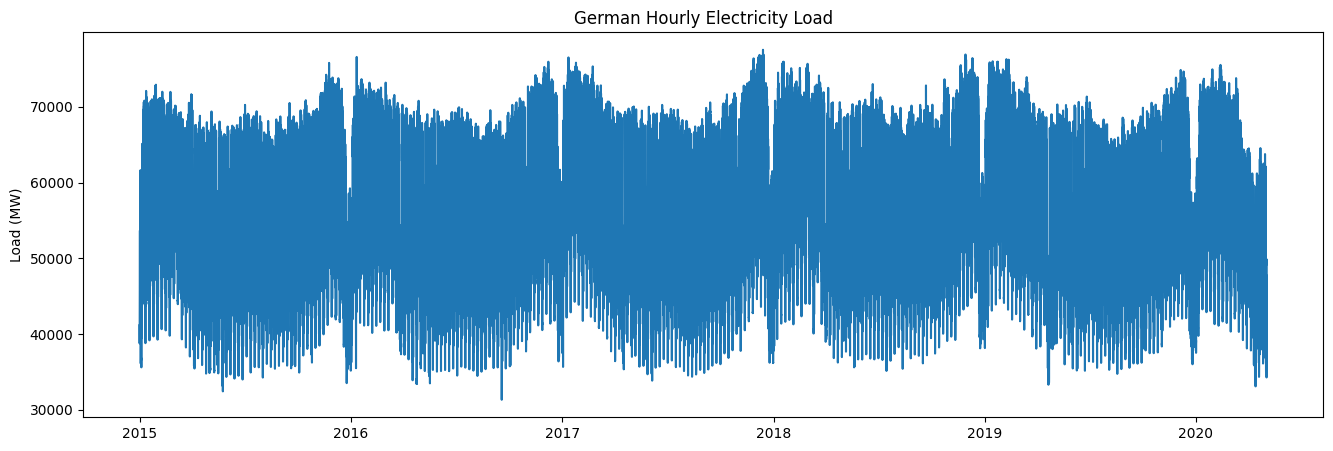

In [7]:
plt.figure(figsize=(16,5))
plt.plot(load)
plt.title('German Hourly Electricity Load')
plt.ylabel('Load (MW)')
plt.show()

### CELL 8: Daily Plot

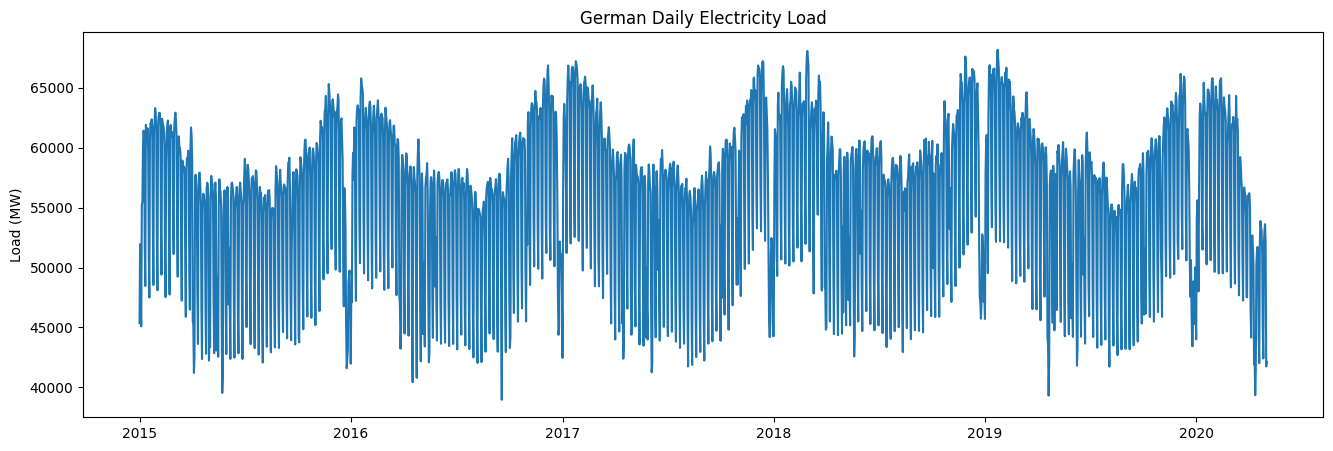

In [8]:
plt.figure(figsize=(16,5))
plt.plot(daily)
plt.title('German Daily Electricity Load')
plt.ylabel('Load (MW)')
plt.show()

### CELL 9: Weekly Plot

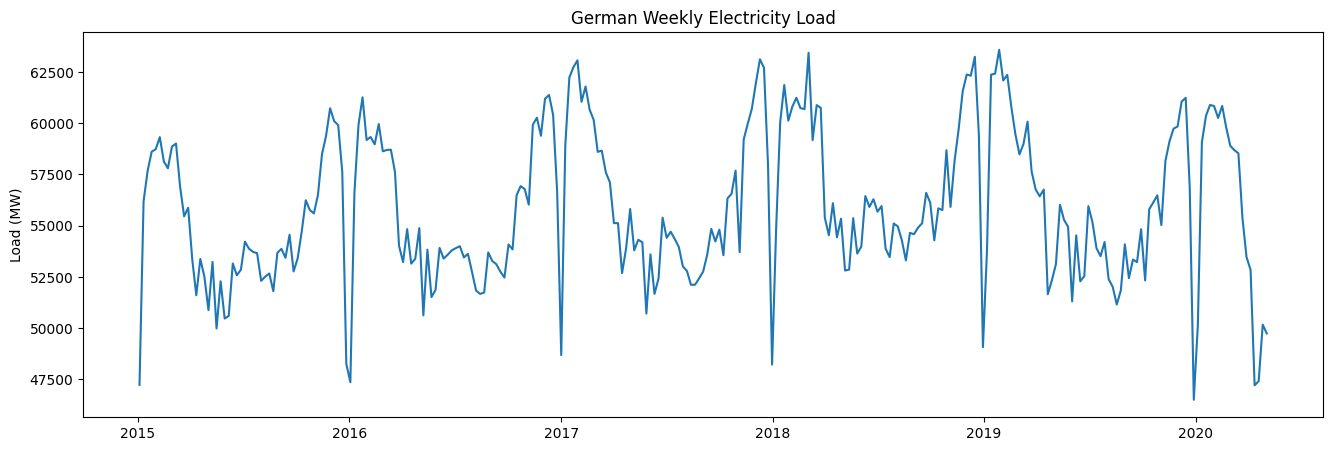

In [9]:
plt.figure(figsize=(16,5))
plt.plot(weekly)
plt.title('German Weekly Electricity Load')
plt.ylabel('Load (MW)')
plt.show()

### CELL 10: Summary Statistics

In [10]:
weekly.describe()

,load
count,279.000000
mean,55850.463802
std,3620.262487
min,46505.309524
25%,53374.247024
50%,55179.630952
75%,58901.008929
max,63587.011905


### CELL 11: Seasonal Decomposition

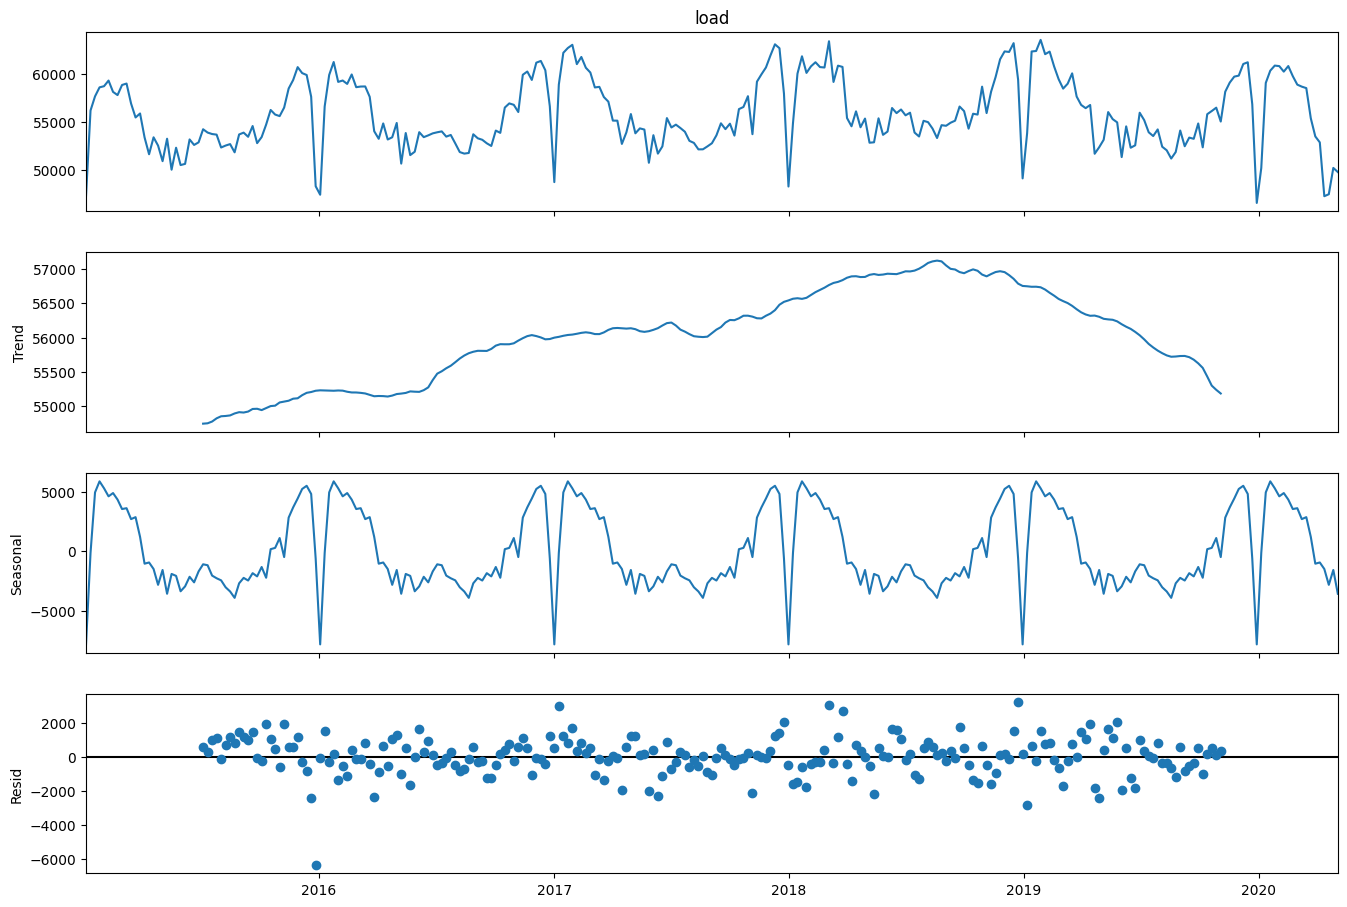

In [11]:
decomposition = seasonal_decompose(
    weekly['load'],
    model='additive',
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

### CELL 12: Rolling Mean and Standard Deviation

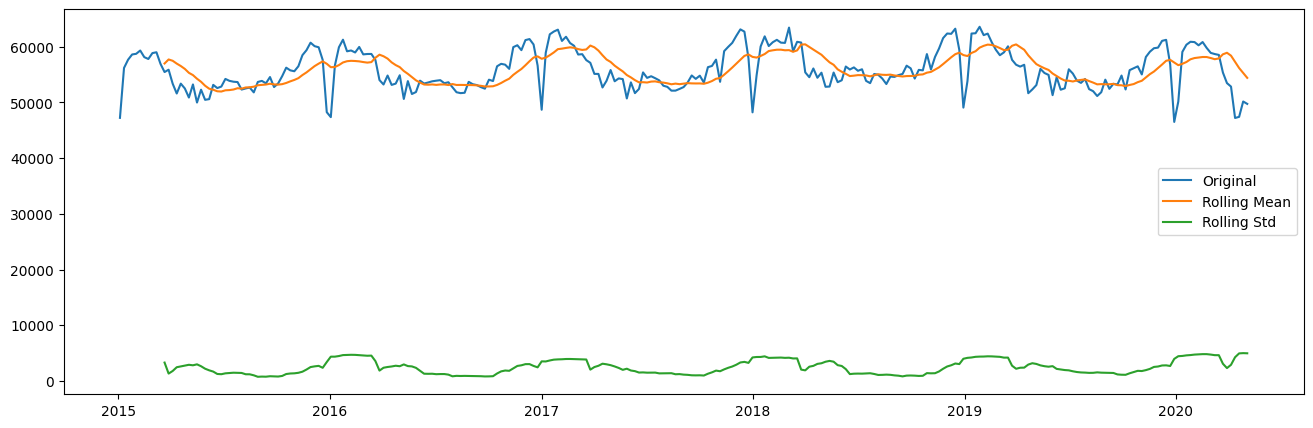

In [12]:
rolling_mean = weekly.rolling(12).mean()
rolling_std = weekly.rolling(12).std()

plt.figure(figsize=(16,5))
plt.plot(weekly,label='Original')
plt.plot(rolling_mean,label='Rolling Mean')
plt.plot(rolling_std,label='Rolling Std')
plt.legend()
plt.show()

### CELL 13: ADF Test

In [13]:
result = adfuller(weekly['load'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

for key,value in result[4].items():
    print(key, value)

ADF Statistic: -4.0173444677853585
p-value: 0.0013223646191624437
1% -3.4548039258751206
5% -2.872304928618605
10% -2.5725063100137175


### CELL 14: KPSS Test

In [14]:
result = kpss(weekly['load'])

print('KPSS Statistic:', result[0])
print('p-value:', result[1])

KPSS Statistic: 0.14972814242112673
p-value: 0.1


/tmp/ipykernel_2550/1978159153.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(weekly['load'])


### CELL 15: Differencing

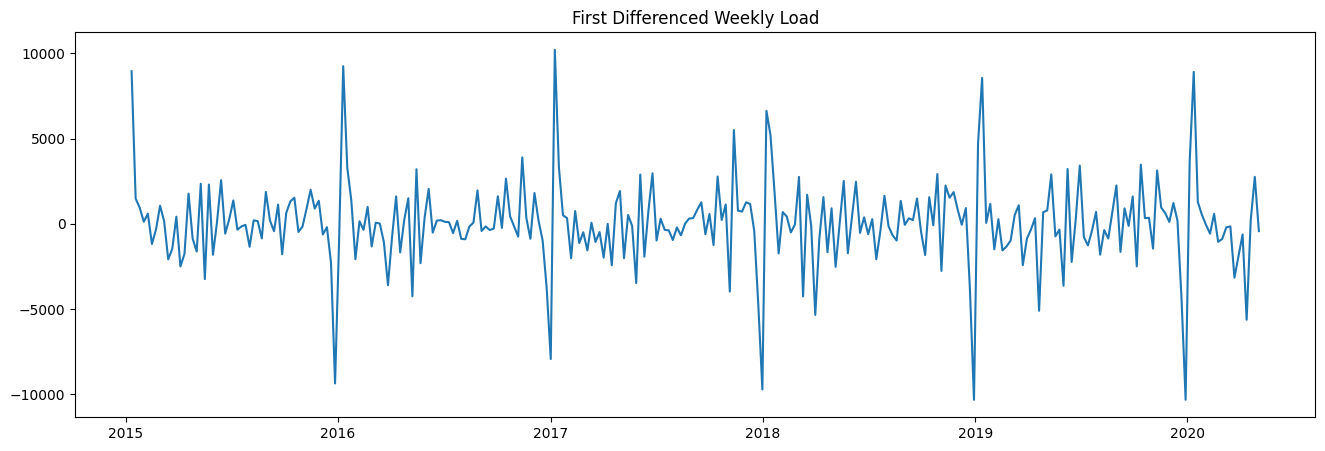

In [15]:
weekly_diff = weekly.diff().dropna()

plt.figure(figsize=(16,5))
plt.plot(weekly_diff)
plt.title('First Differenced Weekly Load')
plt.show()